<a href="https://colab.research.google.com/github/HosseinMasoudi/Sentiment_Analysis_with_Transformers/blob/master/SentimentAnalysisTransformersNLP(WithOutHazm)(Use_Model_in_MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [2]:
!pip install num2fawords
!pip install parsivar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 49.1 MB/s eta 0:00:00


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
import transformers
import JackageNormalizer

from parsivar import Tokenizer
from JackageNormalizer import normalize_persian_text

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from tensorflow.keras import layers, Model ,Input

from transformers import pipeline
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from transformers import DataCollatorWithPadding
from transformers import DistilBertTokenizerFast
from transformers import TFDistilBertForSequenceClassification
from transformers import TFAutoModel

import tqdm as notebook_tqdm

In [4]:
model_name = "HooshvareLab/bert-fa-base-uncased"
num_labels = 2  #positive and negative

testing the pip line...

the model I chose only has a PyTorch checkpoint.

In [ ]:
# Use a pipeline as a high-level helper
pipe = pipeline("text-classification", model="HooshvareLab/bert-fa-base-uncased-sentiment-snappfood", framework="tf")
# Example usage of the pipeline
result = pipe("این غذا خیلی خوشمزه بود!")
print(result)

### 1. Load and Inspect Your Dataset

In [25]:
df = pd.read_csv("/content/cleaned_snappfood copy.csv")
df.head()

,comment,label,comment_length,comment_cleaned
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0,47,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,1,132,قرار بود ساعته برسه ولی نیم ساعت زودتر از موق...
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,0,89,قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...
3,عالی بود همه چه درست و به اندازه و کیفیت خوب، ...,1,99,عالی بود همه چه درست و به اندازه و کیفیت خوب ا...
4,شیرینی وانیلی فقط یک مدل بود.,1,29,شیرینی وانیلی فقط یک مدل بود


In [26]:
df.info()
df.isnull().count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65973 entries, 0 to 65972
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   comment          65973 non-null  object
 1   label            65973 non-null  int64 
 2   comment_length   65973 non-null  int64 
 3   comment_cleaned  65973 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.0+ MB


,0
comment,65973
label,65973
comment_length,65973
comment_cleaned,65973


In [27]:
print(df.shape)
print(df.columns)

(65973, 4)
Index(['comment', 'label', 'comment_length', 'comment_cleaned'], dtype='object')


In [28]:
df = df[['comment', 'label']]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [29]:
tokenizer = Tokenizer()

def clean_text(text):
    text = normalize_persian_text(text)
    tokens = tokenizer.tokenize_words(text)
    return ' '.join(tokens)


In [30]:
df['comment'] = df['comment'].apply(clean_text)

df['comment'].sample(20)

,comment
50751,ویژه چگوارا انصافا عالی خوشطعم نان بزرگ مواد ک...
49127,لطفا گوجهفرنگی خیارشور پیاز نگذارید باتشکر
5085,امشب غذا داغ خوب متشکرم
19231,لذت بردم طعم غذا
37772,خمیر پیتزا خوب بود ترجیح میدم پیتزای ایتالیایی...
25752,کیفیت بود امیدوارم همیشه همینطور کیفیت ادامه بدید
45367,سرد سس سالاد همه ریخته نوشیدنیها مخلوط شده کلا...
57066,زمان انتظار رسیدن سالادی صورت آماده یخچال رستو...
45873,بیسکویت ترد مینو دو عدد کسر
26750,غذا کاملا سرد بود گرمایی نداشت


#### Split into train / val / test

In [31]:
texts = df['comment'].tolist()
labels = df['label'].values

In [32]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

70% → train

15% → validation

15% → test

In [33]:
print(f"Train shape: {len(train_texts)}, Validation shape: {len(val_texts)}, Test shape: {len(test_texts)}\n")

print("Data loaded and processed successfully.")
print(f"Sample of cleaned text:\n ({train_texts[0]}) \n label: {train_labels[0]}")

Train shape: 46181, Validation shape: 9896, Test shape: 9896

Data loaded and processed successfully.
Sample of cleaned text:
 (سیبزمینی روغن مونده درست بو میداد قابل خوردن شکل شمایلش خوب نبود) 
 label: 0


### (Previous version of the model)

Since the output of the SequenceClassification model was fixed and cannot be used in a feed-forward network, we must use the original parsBert model itself.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("HooshvareLab/bert-fa-base-uncased-sentiment-snappfood")

In [ ]:
model = TFAutoModelForSequenceClassification.from_pretrained(
    "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood",
    num_labels=2,
    use_safetensors=True)

### 2. Prepare Text and Tokenize

In [34]:
model_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [35]:
def encode_texts(texts):
    return model_tokenizer(list(texts), truncation=True, padding=True, max_length=128)

In [36]:
train_encoded = encode_texts(train_texts)
val_encoded = encode_texts(val_texts)
test_encoded = encode_texts(test_texts)

convert Encoding to TF DataSet

In [37]:
def make_tf_dataset(encoding, labels, shuffle=False, BATCH_SIZE=16):
    dataset = tf.data.Dataset.from_tensor_slices((dict(encoding), labels))
    if shuffle:
        dataset = dataset.shuffle(1000)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [38]:
train_dataset = make_tf_dataset(train_encoded, train_labels, shuffle=True)
val_dataset = make_tf_dataset(val_encoded, val_labels)
test_dataset = make_tf_dataset(test_encoded, test_labels)

### 3. Laod the Model_Compile the Model_Train the Model

Model architecture:
1. Inputs (all from tf.keras)
2. Transformer backbone (freeze the backbone completely)
3. Extract sentence representation (choose one option)
4. Head (MLP classifier)

In [51]:
def build_sentiment_model(model_name: str):

    input_ids      = Input(shape=(None,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(None,), dtype=tf.int32, name="attention_mask")

    transformer = TFAutoModel.from_pretrained(model_name)
    transformer.trainable = False

    outputs = transformer(input_ids=input_ids, attention_mask=attention_mask)
    cls = outputs.pooler_output

    x = layers.Dense(256, activation="relu", name="Dense")(cls)
    x = layers.Dropout(0.3, name="Dropout")(x)
    logits = layers.Dense(1, activation="sigmoid", dtype="float32", name="OutputSigmoid")(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=logits)
    return model

model = build_sentiment_model(model_name)

model.summary()

Some layers from the model checkpoint at HooshvareLab/bert-fa-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model_3 (TFBertMod  TFBaseModelOutputWithPooli   1628413   ['input_ids[0][0]',           
 el)                         ngAndCrossAttentions(last_   44         'attention_mask[0][0]']      
                             hidden_state=(None, None,                                      

optimizer with AdamW

In [52]:
optimizer_adamW = tf.keras.optimizers.AdamW(
    learning_rate=1e-5,
    weight_decay=0.01,
    clipnorm=1.0,
)

model.compile(
    optimizer=optimizer_adamW,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")]
)

optimizer with Adam

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3, clipnorm=1.0),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

In [53]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_model_stage1.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
2886/2887 [============================>.] - ETA: 0s - loss: 0.4924 - accuracy: 0.4893

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


2887/2887 [==============================] - 362s 121ms/step - loss: 0.4923 - accuracy: 0.4893 - val_loss: 0.4157 - val_accuracy: 0.4893 - lr: 0.0020
Epoch 2/20
2887/2887 [==============================] - 343s 119ms/step - loss: 0.4575 - accuracy: 0.4893 - val_loss: 0.4137 - val_accuracy: 0.4893 - lr: 0.0020
Epoch 3/20
2887/2887 [==============================] - 341s 118ms/step - loss: 0.4521 - accuracy: 0.4893 - val_loss: 0.4047 - val_accuracy: 0.4893 - lr: 0.0020
Epoch 4/20
1985/2887 [===================>..........] - ETA: 1:31 - loss: 0.4441 - accuracy: 0.4873

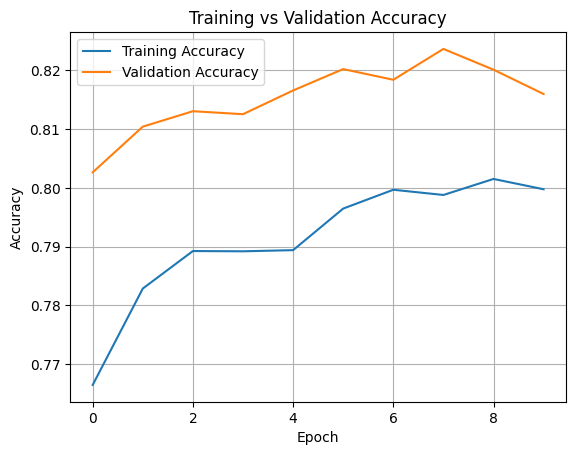

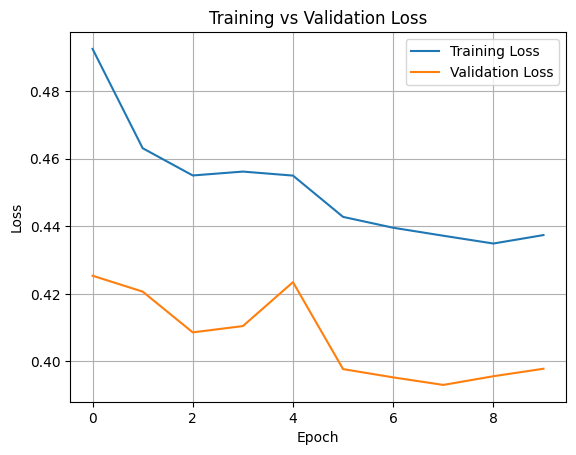

In [ ]:
# Accuracy
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 4. Evaluate on TEST set

In [ ]:
print("Final Evaluation on Test Set\n")
loss, accuracy = model.evaluate(test_dataset)

print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

Final Evaluation on Test Set
619/619 [==============================] - 60s 92ms/step - loss: 0.3977 - sparse_categorical_accuracy: 0.8198


[0.3976549804210663, 0.8198261857032776]

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support,
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score)

y_true_list, y_prob_list = [], []
for (features, y) in test_dataset:
    probs = tf.nn.softmax(model.predict(features, verbose=0), axis=1).numpy()
    y_true_list.append(y.numpy()); y_prob_list.append(probs)

y_true = np.concatenate(y_true_list)
y_pred_prob = np.concatenate(y_prob_list)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced Acc:", balanced_accuracy_score(y_true, y_pred))
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
print("F1 (macro), F1 (weighted):", f1_m, f1_w)
print("MCC:", matthews_corrcoef(y_true, y_pred), "Kappa:", cohen_kappa_score(y_true, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

### 5. Save the Fine-Tuned Model

saving on GoogleDrive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


model.save_pretrained('/content/drive/MyDrive/mySentimentAnalysis_model')
tokenizer.save_pretrained('/content/drive/MyDrive/mySentimentAnalysis_model')